In [35]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from assignments.helpers import preprocess_data
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder

In [3]:
preprocessed_data = preprocess_data()
preprocessed_data.shape

(1460, 20)

In [4]:
# Dropping the single record with a genuinely missing BsmtExposure (basement exists, value missing)
genuine_missing = preprocessed_data["BsmtExposure"].isnull() & (preprocessed_data["TotalBsmtSF"] > 0)
print("Rows dropped:", genuine_missing.sum())
preprocessed_data = preprocessed_data[~genuine_missing].copy()
print(preprocessed_data.shape)

Rows dropped: 1
(1459, 20)


In [5]:
# Drop the two known anomalous records: very large, top-quality houses with implausibly low prices
anomalous = (preprocessed_data["GrLivArea"] > 4000) & (preprocessed_data["SalePrice"] < 300000)
print("Rows dropped:", anomalous.sum())          # expected: 2
preprocessed_data = preprocessed_data[~anomalous].copy()
print(preprocessed_data.shape)                    # expected: (1457, 20)

Rows dropped: 2
(1457, 20)


In [6]:
# Drop extreme LotArea records (huge lots with ordinary prices, no matching price signal)
extreme_lot = preprocessed_data["LotArea"] > 100000
print("Rows dropped:", extreme_lot.sum())          # expected: 4
preprocessed_data = preprocessed_data[~extreme_lot].copy()
print(preprocessed_data.shape)                      # expected: (1453, 20)

Rows dropped: 4
(1453, 20)


In [7]:
preprocessed_data.isnull().sum()

LotArea            0
LotConfig          0
Neighborhood       0
BldgType           0
OverallQual        0
YearBuilt          0
MasVnrArea         8
BsmtExposure      37
BsmtFinType1      37
TotalBsmtSF        0
HeatingQC          0
CentralAir         0
GrLivArea          0
FullBath           0
Fireplaces         0
FireplaceQu      690
GarageFinish      81
GarageCars         0
SaleCondition      0
SalePrice          0
dtype: int64

In [8]:
price_bins = pd.qcut(preprocessed_data["SalePrice"], q=5, labels=False)

In [9]:
train_data, test_data = train_test_split(
    preprocessed_data,
    test_size=0.25,
    random_state=42,
    stratify=price_bins
)

In [10]:
print(train_data.shape)
print(test_data.shape) 

(1089, 20)
(364, 20)


In [11]:
masvnr_imputer = SimpleImputer(strategy="median")

In [12]:
masvnr_imputer

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [13]:
train_data[train_data["MasVnrArea"].isnull()]

,LotArea,LotConfig,Neighborhood,BldgType,OverallQual,YearBuilt,MasVnrArea,BsmtExposure,BsmtFinType1,TotalBsmtSF,HeatingQC,CentralAir,GrLivArea,FullBath,Fireplaces,FireplaceQu,GarageFinish,GarageCars,SaleCondition,SalePrice
1243,13891,Inside,NridgHt,1Fam,10,2006,NaN,Gd,GLQ,2076,Ex,Y,2076,2,1,Gd,Fin,3,Partial,465000
234,7851,Inside,Gilbert,1Fam,6,2002,NaN,No,GLQ,860,Ex,Y,1960,2,2,TA,Fin,2,Normal,216500
1278,9473,Inside,CollgCr,1Fam,8,2002,NaN,No,GLQ,1128,Ex,Y,2031,2,1,Gd,RFn,2,Normal,237000
977,4274,Inside,Somerst,TwnhsE,7,2006,NaN,No,GLQ,1241,Ex,Y,1241,1,0,NaN,Fin,2,Partial,199900
936,10083,Inside,SawyerW,1Fam,7,2003,NaN,No,GLQ,1176,Ex,Y,1200,2,0,NaN,RFn,2,Normal,184900


In [14]:
test_data[test_data["MasVnrArea"].isnull()]

,LotArea,LotConfig,Neighborhood,BldgType,OverallQual,YearBuilt,MasVnrArea,BsmtExposure,BsmtFinType1,TotalBsmtSF,HeatingQC,CentralAir,GrLivArea,FullBath,Fireplaces,FireplaceQu,GarageFinish,GarageCars,SaleCondition,SalePrice
650,8125,Inside,Somerst,1Fam,7,2007,NaN,No,Unf,813,Ex,Y,1665,2,0,NaN,RFn,2,Normal,205950
973,11639,Corner,Somerst,1Fam,7,2007,NaN,No,Unf,1428,Ex,Y,1428,2,0,NaN,Fin,2,Partial,182000
529,32668,CulDSac,Crawfor,1Fam,6,1957,NaN,No,Rec,2035,TA,Y,2515,3,2,TA,RFn,2,Alloca,200624


In [15]:


train_data["MasVnrArea"] = masvnr_imputer.fit_transform(train_data[["MasVnrArea"]])
test_data["MasVnrArea"] = masvnr_imputer.transform(test_data[["MasVnrArea"]])

print("Median learned from train:", masvnr_imputer.statistics_)
print("Missing in train after imputation:", train_data["MasVnrArea"].isnull().sum())
print("Missing in test after imputation:", test_data["MasVnrArea"].isnull().sum())

Median learned from train: [0.]
Missing in train after imputation: 0
Missing in test after imputation: 0


In [16]:
train_data.isnull().sum()

LotArea            0
LotConfig          0
Neighborhood       0
BldgType           0
OverallQual        0
YearBuilt          0
MasVnrArea         0
BsmtExposure      28
BsmtFinType1      28
TotalBsmtSF        0
HeatingQC          0
CentralAir         0
GrLivArea          0
FullBath           0
Fireplaces         0
FireplaceQu      526
GarageFinish      58
GarageCars         0
SaleCondition      0
SalePrice          0
dtype: int64

In [17]:
train_data[["BsmtFinType1", "FireplaceQu", "GarageFinish", "BsmtExposure"]].info()

<class 'pandas.DataFrame'>
Index: 1089 entries, 942 to 161
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   BsmtFinType1  1061 non-null   str  
 1   FireplaceQu   563 non-null    str  
 2   GarageFinish  1031 non-null   str  
 3   BsmtExposure  1061 non-null   str  
dtypes: str(4)
memory usage: 42.5 KB


In [18]:
train_data[["BsmtFinType1", "FireplaceQu", "GarageFinish", "BsmtExposure"]].sample(10)

,BsmtFinType1,FireplaceQu,GarageFinish,BsmtExposure
1382,Unf,NaN,Unf,No
1203,Unf,TA,Unf,No
1376,Rec,NaN,Unf,Mn
888,ALQ,TA,Unf,Gd
1064,BLQ,Po,RFn,Mn
1324,Unf,Gd,RFn,Av
922,GLQ,Gd,Fin,No
1261,Rec,NaN,Unf,No
1322,GLQ,TA,RFn,No
1455,Unf,TA,RFn,No


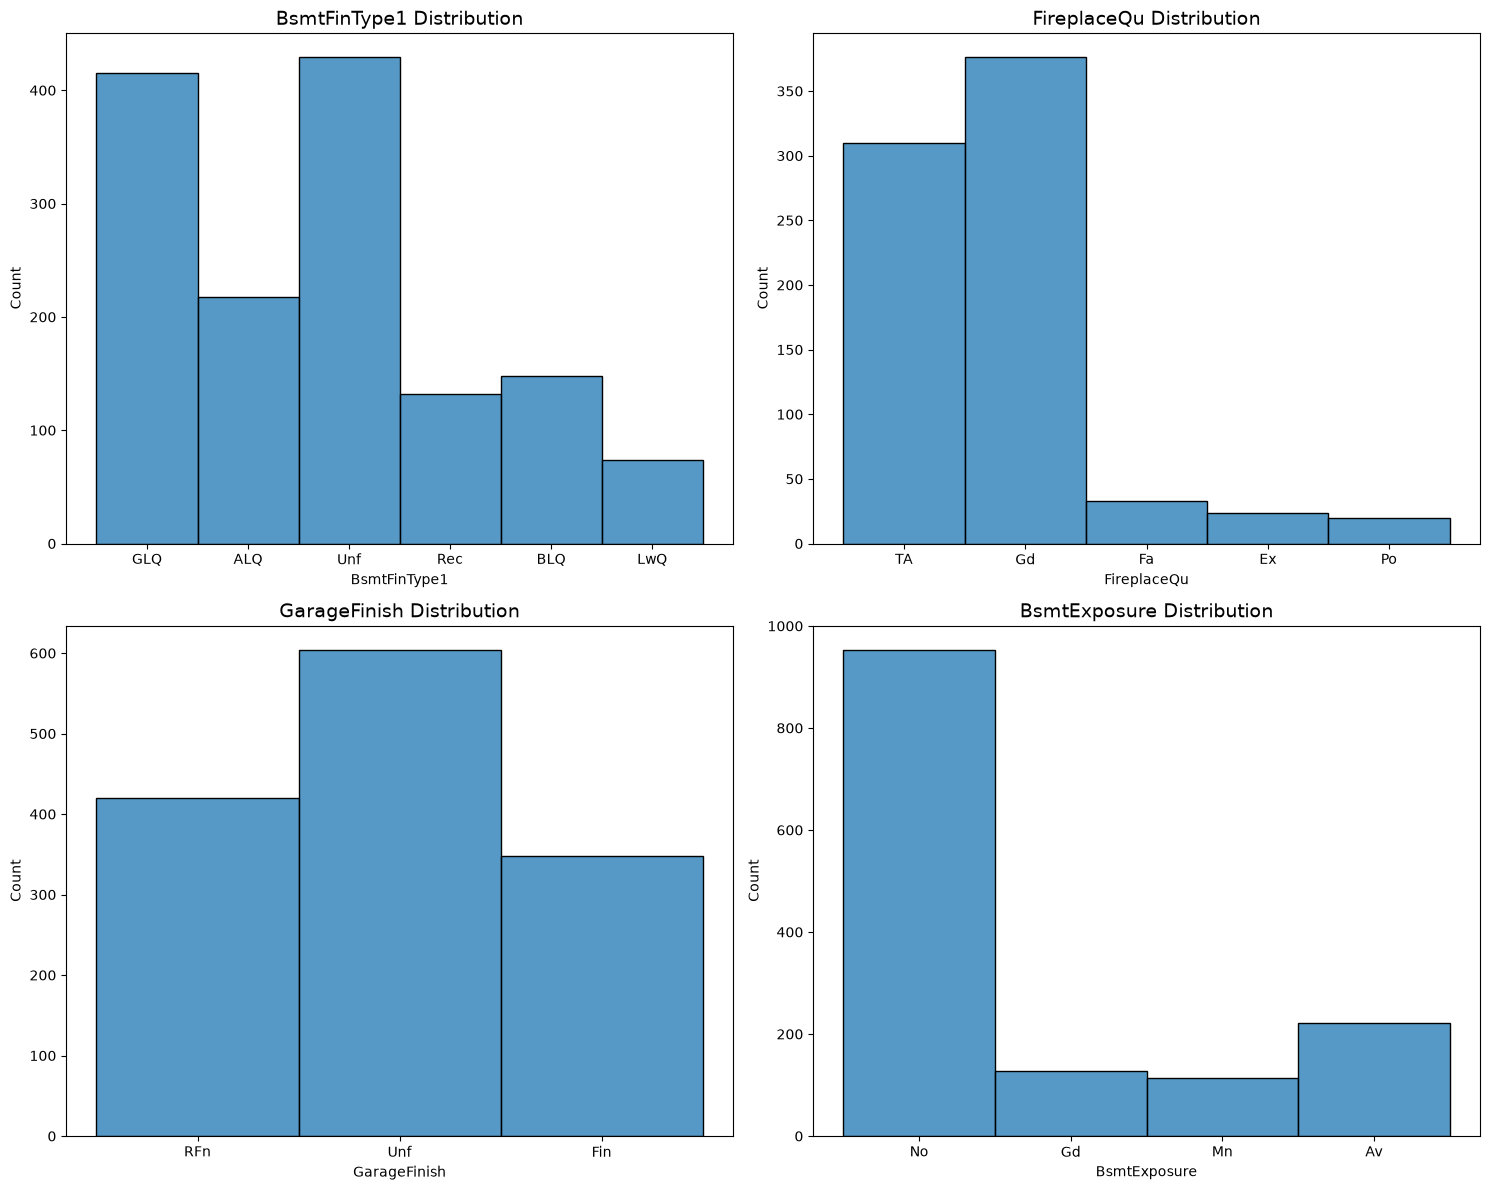

In [19]:
ordinal_col = ["BsmtFinType1", "FireplaceQu", "GarageFinish", "BsmtExposure"]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(ordinal_col):
    sns.histplot(preprocessed_data[col], ax=axes[i], fill=True)
    axes[i].set_title(f"{col} Distribution", fontsize=14)

plt.tight_layout()
plt.show()

In [20]:
len(train_data.columns)

20

In [21]:
none_cols = ["BsmtFinType1", "FireplaceQu", "GarageFinish", "BsmtExposure"]

none_imputer = SimpleImputer(strategy="constant", fill_value="None")

train_data[none_cols] = none_imputer.fit_transform(train_data[none_cols])
test_data[none_cols] = none_imputer.transform(test_data[none_cols])

print("Missing in train after imputation:\n", train_data[none_cols].isnull().sum())
print("\nMissing in test after imputation:\n", test_data[none_cols].isnull().sum())

Missing in train after imputation:
 BsmtFinType1    0
FireplaceQu     0
GarageFinish    0
BsmtExposure    0
dtype: int64

Missing in test after imputation:
 BsmtFinType1    0
FireplaceQu     0
GarageFinish    0
BsmtExposure    0
dtype: int64


In [22]:
len(train_data.columns)

20

In [23]:
train_data.sample(5)

,LotArea,LotConfig,Neighborhood,BldgType,OverallQual,YearBuilt,MasVnrArea,BsmtExposure,BsmtFinType1,TotalBsmtSF,HeatingQC,CentralAir,GrLivArea,FullBath,Fireplaces,FireplaceQu,GarageFinish,GarageCars,SaleCondition,SalePrice
224,13472,Inside,NridgHt,1Fam,10,2003,922.0,Gd,GLQ,2392,Ex,Y,2392,2,1,Ex,Fin,3,Normal,386250
1384,9060,Inside,Edwards,1Fam,6,1939,0.0,Mn,Rec,560,TA,Y,1258,1,0,None,Unf,1,Normal,105000
970,10800,Inside,NAmes,1Fam,4,1949,0.0,No,Unf,720,TA,N,1192,1,0,None,None,0,Abnorml,135000
994,12456,FR2,NridgHt,1Fam,10,2006,230.0,Gd,GLQ,1700,Ex,Y,1718,2,1,Gd,Fin,3,Normal,337500
1003,11500,Corner,NWAmes,Duplex,5,1976,164.0,No,Unf,1680,Fa,Y,1680,2,0,None,Unf,2,Normal,136905


In [24]:
train_data.isnull().sum()

LotArea          0
LotConfig        0
Neighborhood     0
BldgType         0
OverallQual      0
YearBuilt        0
MasVnrArea       0
BsmtExposure     0
BsmtFinType1     0
TotalBsmtSF      0
HeatingQC        0
CentralAir       0
GrLivArea        0
FullBath         0
Fireplaces       0
FireplaceQu      0
GarageFinish     0
GarageCars       0
SaleCondition    0
SalePrice        0
dtype: int64

In [25]:
print(train_data.shape, test_data.shape)
print(train_data.isnull().sum().sum(), test_data.isnull().sum().sum())  # expect 0 0

(1089, 20) (364, 20)
0 0


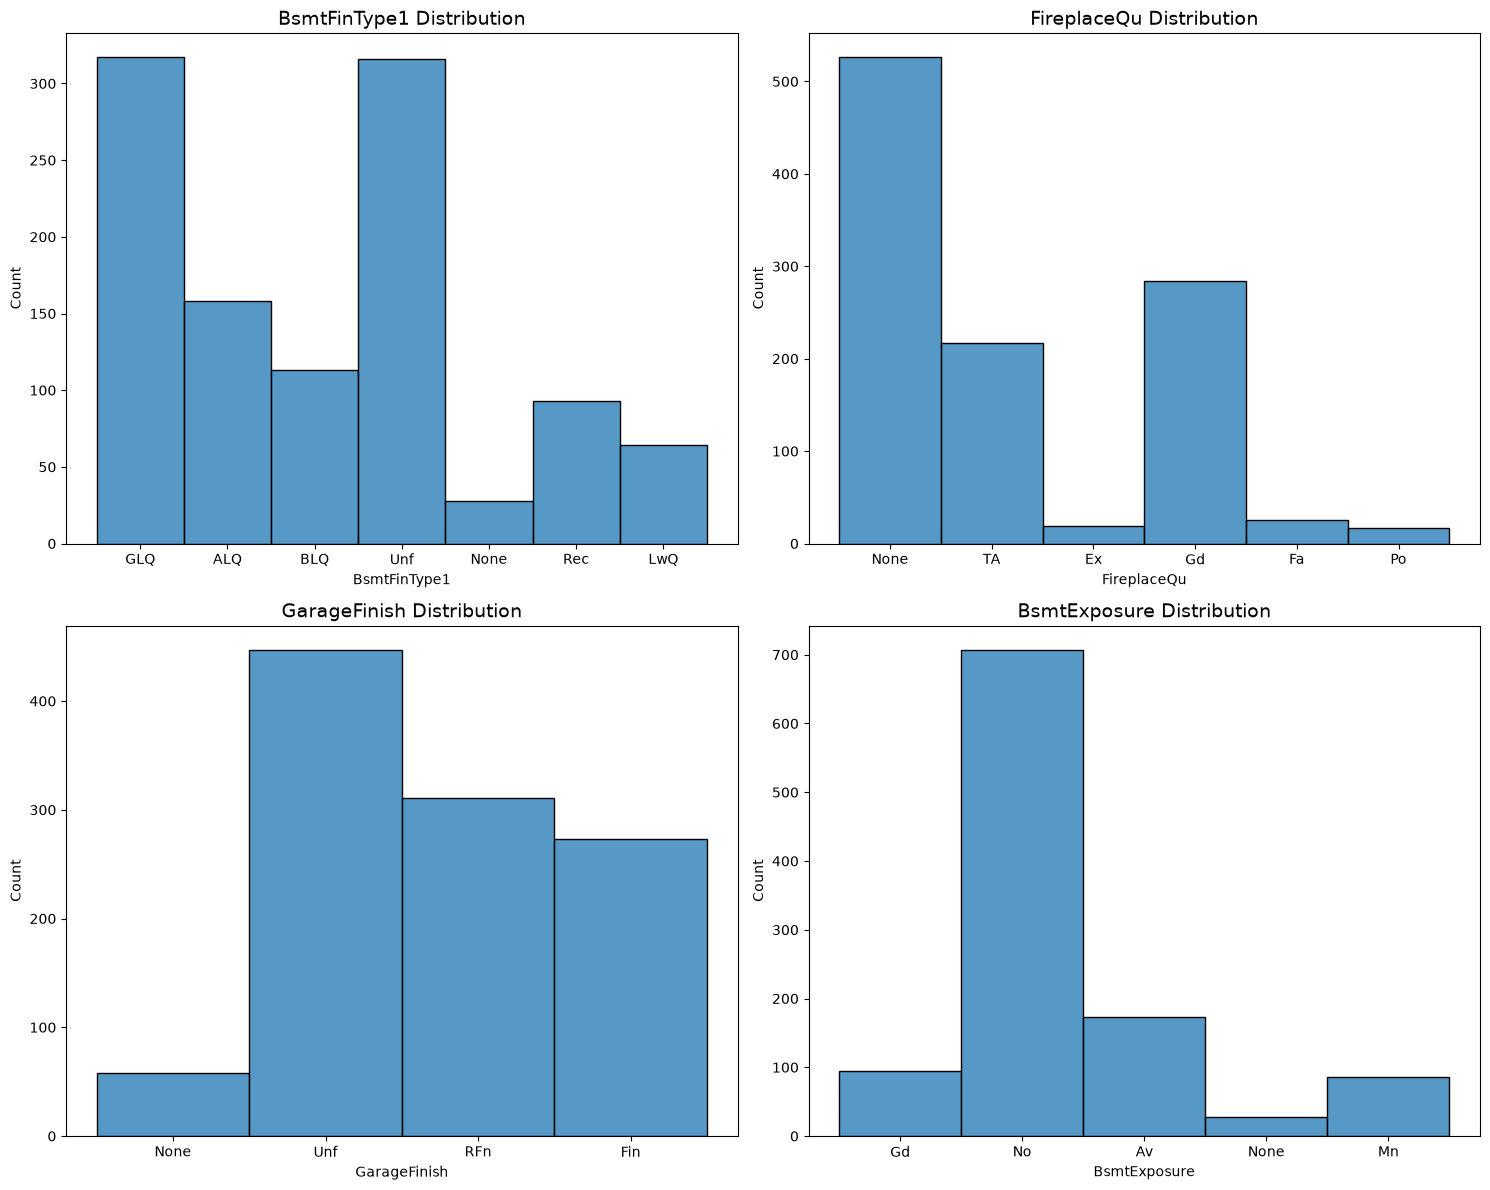

In [26]:
ordinal_col = ["BsmtFinType1", "FireplaceQu", "GarageFinish", "BsmtExposure"]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(ordinal_col):
    sns.histplot(train_data[col], ax=axes[i], fill=True)
    axes[i].set_title(f"{col} Distribution", fontsize=14)

plt.tight_layout()
plt.show()

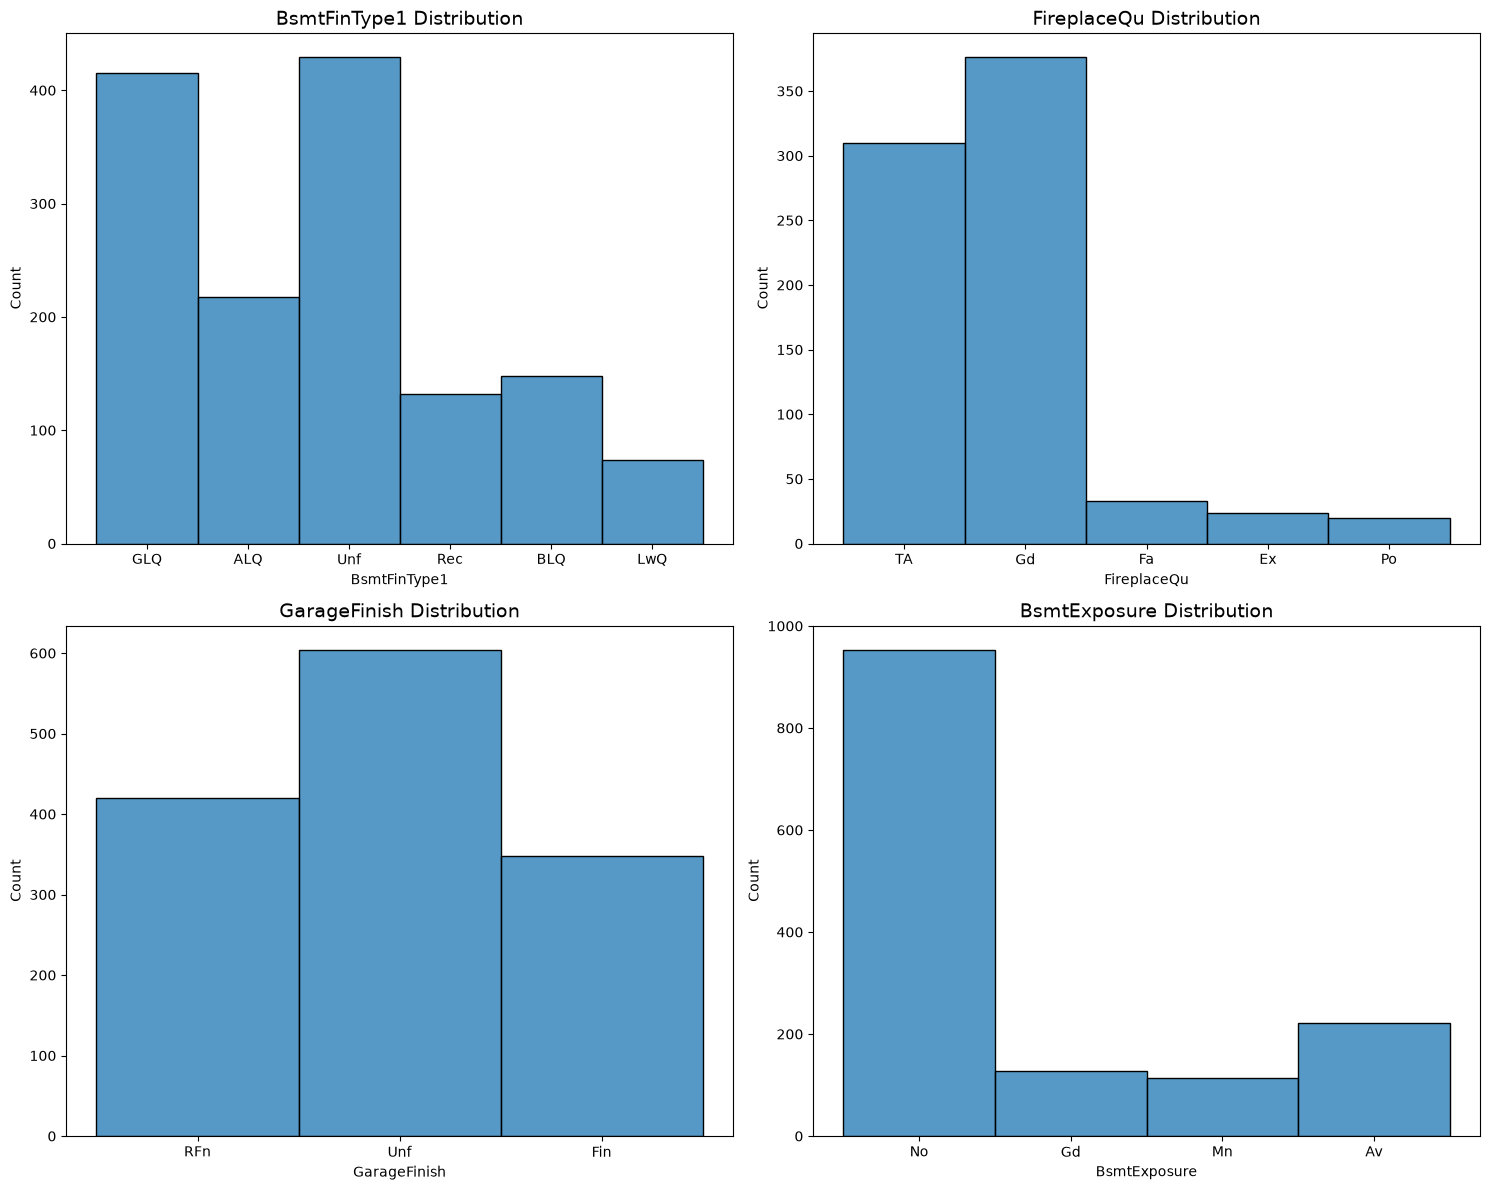

In [27]:
ordinal_col = ["BsmtFinType1", "FireplaceQu", "GarageFinish", "BsmtExposure"]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(ordinal_col):
    sns.histplot(preprocessed_data[col], ax=axes[i], fill=True)
    axes[i].set_title(f"{col} Distribution", fontsize=14)

plt.tight_layout()
plt.show()

In [28]:
ordinal_col = ["BsmtFinType1", "FireplaceQu", "GarageFinish", "BsmtExposure"]

print(preprocessed_data[ordinal_col].describe())

       BsmtFinType1 FireplaceQu GarageFinish BsmtExposure
count          1416         763         1372         1416
unique            6           5            3            4
top             Unf          Gd          Unf           No
freq            429         376          604          953


**outliers handling**

In [29]:
numerical_cols = ["LotArea", "YearBuilt", "MasVnrArea", "TotalBsmtSF", 
                   "GrLivArea", "FullBath", "Fireplaces", "GarageCars", "SalePrice"]

for col in numerical_cols:
    Q1 = preprocessed_data[col].quantile(0.25)
    Q3 = preprocessed_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = preprocessed_data[(preprocessed_data[col] < lower_bound) | (preprocessed_data[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

LotArea: 70 outliers
YearBuilt: 7 outliers
MasVnrArea: 95 outliers
TotalBsmtSF: 60 outliers
GrLivArea: 29 outliers
FullBath: 0 outliers
Fireplaces: 4 outliers
GarageCars: 5 outliers
SalePrice: 63 outliers


In [30]:
print(train_data[train_data["GrLivArea"] > 4000][["GrLivArea", "OverallQual", "SalePrice"]])

      GrLivArea  OverallQual  SalePrice
1182       4476           10     745000


In [31]:
print(test_data[test_data["GrLivArea"] > 4000][["GrLivArea", "OverallQual", "SalePrice"]])

     GrLivArea  OverallQual  SalePrice
691       4316           10     755000


<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

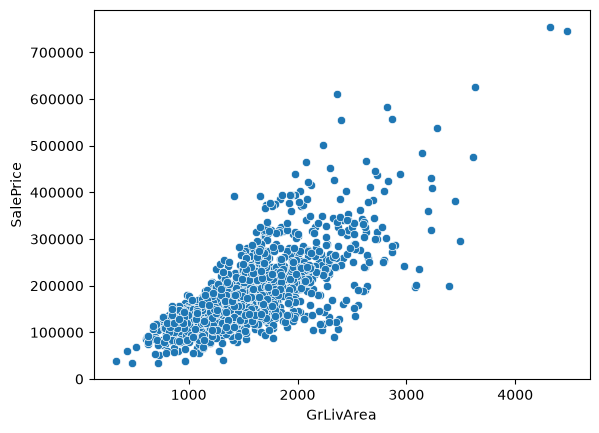

In [32]:
sns.scatterplot(x="GrLivArea", y="SalePrice", data=preprocessed_data)

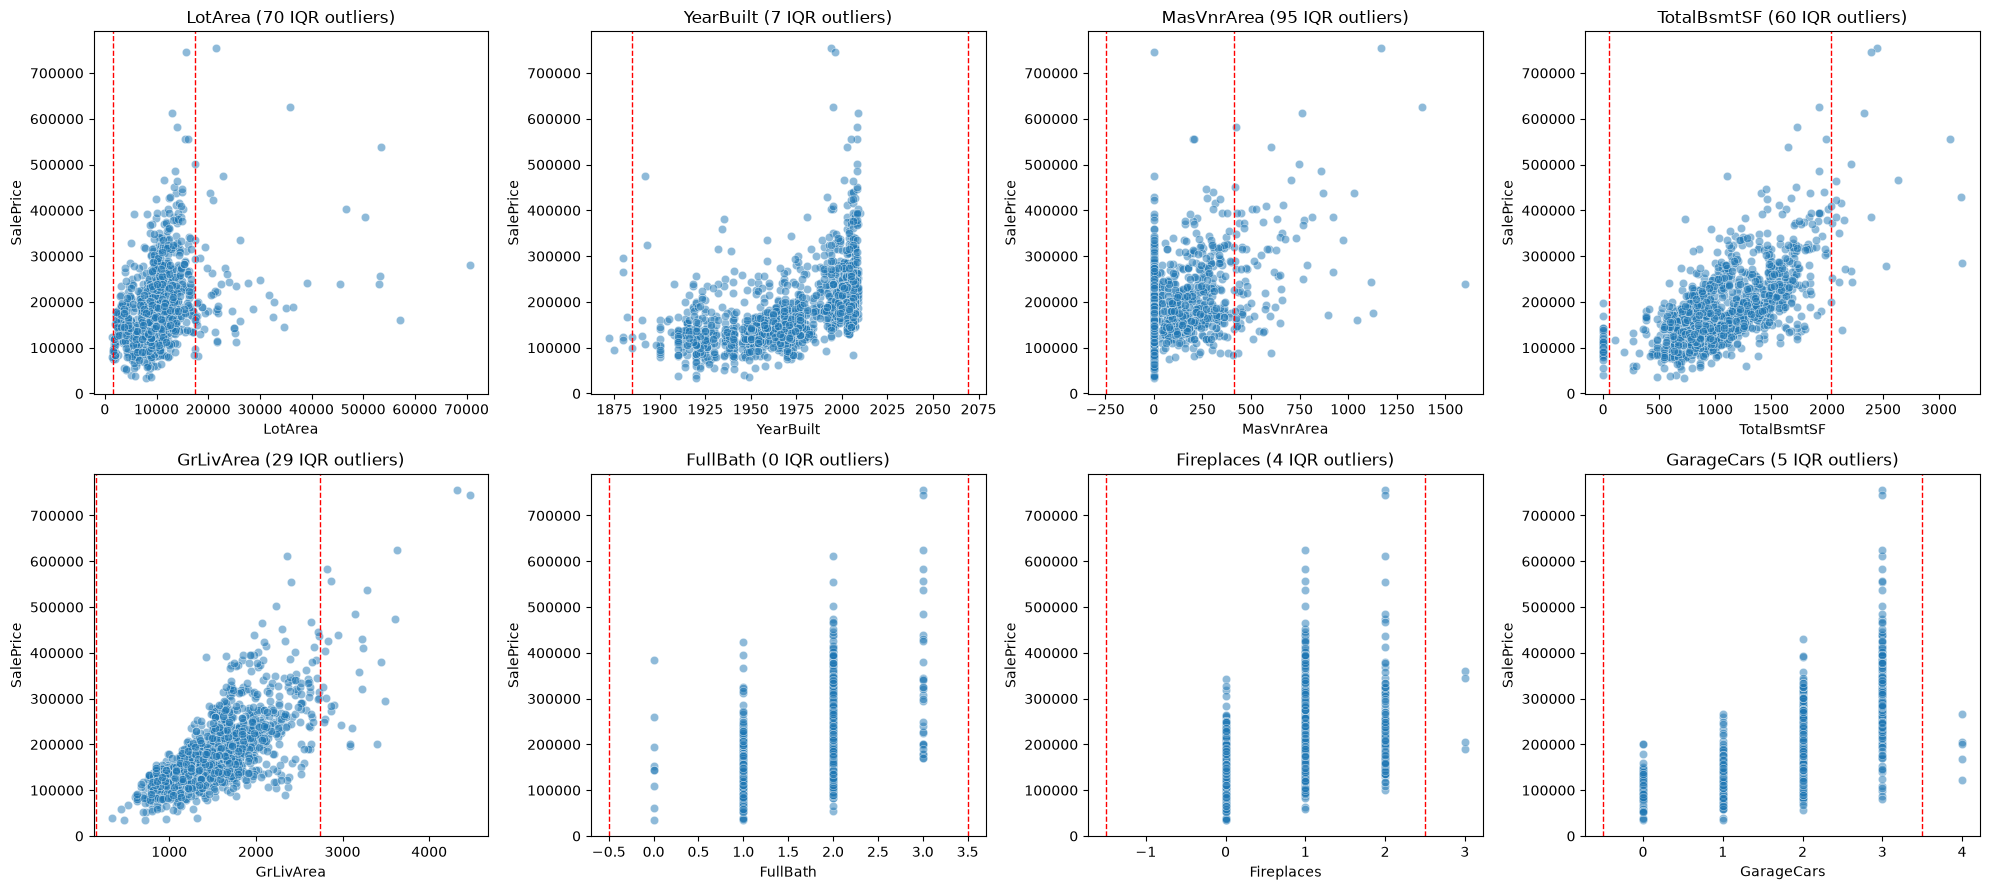

In [33]:
num_predictors = ["LotArea", "YearBuilt", "MasVnrArea", "TotalBsmtSF",
                  "GrLivArea", "FullBath", "Fireplaces", "GarageCars"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flatten(), num_predictors):
    q1, q3 = preprocessed_data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((preprocessed_data[col] < lo) | (preprocessed_data[col] > hi)).sum()

    sns.scatterplot(data=preprocessed_data, x=col, y="SalePrice", alpha=0.5, ax=ax)
    ax.axvline(lo, color="red", linestyle="--", linewidth=1)
    ax.axvline(hi, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{col} ({n_out} IQR outliers)")

plt.tight_layout()
plt.show()

In [34]:
train_data.head()

,LotArea,LotConfig,Neighborhood,BldgType,OverallQual,YearBuilt,MasVnrArea,BsmtExposure,BsmtFinType1,TotalBsmtSF,HeatingQC,CentralAir,GrLivArea,FullBath,Fireplaces,FireplaceQu,GarageFinish,GarageCars,SaleCondition,SalePrice
942,7711,Inside,Edwards,Duplex,4,1977,0.0,Gd,GLQ,1440,TA,Y,1440,2,0,None,None,0,Abnorml,150000
173,10197,Inside,NAmes,1Fam,6,1961,491.0,No,ALQ,1362,TA,Y,1362,1,1,TA,Unf,2,Normal,163000
373,10634,Inside,NAmes,1Fam,5,1953,0.0,No,BLQ,608,TA,Y,1319,1,0,None,Unf,1,Normal,123000
348,2448,Inside,NridgHt,Twnhs,7,2003,106.0,No,GLQ,764,Ex,Y,1626,2,0,None,RFn,2,Normal,154000
343,8849,Inside,NridgHt,TwnhsE,9,2005,616.0,No,GLQ,1684,Ex,Y,1684,2,1,Ex,RFn,2,Normal,266000


**Ordinal Encoding**

In [36]:

ordinal_cols = ["BsmtExposure", "BsmtFinType1", "HeatingQC", "FireplaceQu", "GarageFinish"]

category_orders = [
    ["None", "No", "Mn", "Av", "Gd"],                          # BsmtExposure
    ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],        # BsmtFinType1
    ["Po", "Fa", "TA", "Gd", "Ex"],                            # HeatingQC
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],                    # FireplaceQu
    ["None", "Unf", "RFn", "Fin"],                             # GarageFinish
]

ordinal_encoder = OrdinalEncoder(categories=category_orders)

train_data[ordinal_cols] = ordinal_encoder.fit_transform(train_data[ordinal_cols])
test_data[ordinal_cols] = ordinal_encoder.transform(test_data[ordinal_cols])

train_data[ordinal_cols].head()

,BsmtExposure,BsmtFinType1,HeatingQC,FireplaceQu,GarageFinish
942,4.0,6.0,2.0,0.0,0.0
173,1.0,5.0,2.0,3.0,1.0
373,1.0,4.0,2.0,0.0,1.0
348,1.0,6.0,4.0,0.0,2.0
343,1.0,6.0,4.0,5.0,2.0
